<a href="https://colab.research.google.com/github/npandolfi/Keratoconus-ComputerVision/blob/main/Keratoconus_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keratoconus Computer Vision Model

## Install Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from PIL import Image
from google.colab import drive
import os

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Data Processing

In [2]:
# Pre-processing and Data Augmentation
# Standardization to 224x224 pixels as per clinical study parameters
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # Simulation of varying exam conditions
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

# Define specific project path
data_dir = '/content/drive/MyDrive/Data Science Projects/Keratoconus/dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Custom Dataset Function

In [4]:
from torch.utils.data import Dataset

class KeratoconusCaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        root_dir: Path to the folder containing 'Normal', 'Suspect', 'Keratoconus'
        """
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['Normal', 'Suspect', 'Keratoconus']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []

        # Traverse: Class Folder -> Case Folder -> 7 Images
        for cls in self.classes:
            class_path = os.path.join(self.root_dir, cls)
            if not os.path.isdir(class_path):
                continue

            for case_name in os.listdir(class_path):
                case_path = os.path.join(class_path, case_name)
                if not os.path.isdir(case_path):
                    continue

                # Get all image paths in the case folder
                images = [os.path.join(case_path, f) for f in os.listdir(case_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                # Verify we have exactly 7 maps as expected by the hybrid model
                if len(images) == 7:
                    images.sort() # Ensure consistent map order (e.g., Map 1 is always Anterior Sagittal)
                    self.samples.append((images, self.class_to_idx[cls]))
                else:
                    print(f"Warning: Case {case_name} has {len(images)} images (Expected 7). Skipping.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_paths, label = self.samples[idx]
        stacked_images = []

        for p in img_paths:
            img = Image.open(p).convert('RGB')
            if self.transform:
                img = self.transform(img)
            stacked_images.append(img)

        # Returns a tensor of shape (7, 3, 224, 224)
        return torch.stack(stacked_images), label

In [5]:
train = '/content/drive/MyDrive/Data Science Projects/Keratoconus/dataset/Train_Validation sets/Train_Validation sets/'

case_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Standard clinical map size [cite: 590]
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Initialize the Dataset
dataset = KeratoconusCaseDataset(root_dir=train, transform=case_transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Verification
print(f"Total valid cases found: {len(dataset)}")
sample_batch, labels = next(iter(dataloader))
print(f"Batch Shape: {sample_batch.shape}") # Expected: [batch, 7, 3, 224, 224]

Total valid cases found: 423
Batch Shape: torch.Size([4, 7, 3, 224, 224])


## Train/Test Split

In [6]:
# Define the split sizes (80% training, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Randomly split the 423 cases
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create the missing loaders
# Using a batch size of 4 to match your previous output: torch.Size([4, 7, 3, 224, 224])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print(f"Train loader defined with {len(train_loader)} batches.")
print(f"Validation loader defined with {len(val_loader)} batches.")

Train loader defined with 85 batches.
Validation loader defined with 22 batches.


## Simple CNN Model

In [7]:
class SimpleKCNNet(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleKCNNet, self).__init__()

        # 1. Feature Extractor: Simple 3-layer CNN
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # 3 input channels (RGB)
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Reduces 224x224 to 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Reduces 112x112 to 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)) # Reduces each map to a single 64-length vector
        )

        # 2. Classifier: Takes combined features from all 7 maps
        # 7 maps * 64 features = 448 total input features
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, 7, 3, 224, 224]
        batch_size = x.size(0)
        map_features = []

        # Loop through each of the 7 corneal maps
        for i in range(7):
            one_map = x[:, i, :, :, :] # [batch, 3, 224, 224]
            feat = self.conv_layers(one_map) # [batch, 64, 1, 1]
            feat = torch.flatten(feat, 1) # [batch, 64]
            map_features.append(feat)

        # Concatenate features from all 7 maps: [batch, 448]
        combined = torch.cat(map_features, dim=1)

        # Final classification (Normal, Suspect, Keratoconus)
        return self.classifier(combined)

# Initialize for your specific device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleKCNNet(num_classes=3).to(device)
print(model)

SimpleKCNNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Linear(in_features=448, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Training

In [18]:
# Define Weights & Loss (Adjust based on your actual class counts)
# Higher weights for rarer classes like 'Suspect' and 'Keratoconus'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = torch.tensor([1.2, 3.5, 1.0]).to(device) # [Normal, Suspect, KCN]
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_baseline(model, train_loader, val_loader, epochs=30):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss/len(train_loader):.4f}")

    # 2. Evaluation & Confusion Matrix
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Plotting the results
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Suspect', 'KCN'],
                yticklabels=['Normal', 'Suspect', 'KCN'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Baseline KCN Confusion Matrix')
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=['Normal', 'Suspect', 'KCN']))

Epoch 1/30 - Loss: 0.9127
Epoch 2/30 - Loss: 0.7964
Epoch 3/30 - Loss: 0.7647
Epoch 4/30 - Loss: 0.6799
Epoch 5/30 - Loss: 0.6278
Epoch 6/30 - Loss: 0.5988
Epoch 7/30 - Loss: 0.6720
Epoch 8/30 - Loss: 0.5824
Epoch 9/30 - Loss: 0.5641
Epoch 10/30 - Loss: 0.5322
Epoch 11/30 - Loss: 0.4835
Epoch 12/30 - Loss: 0.4346
Epoch 13/30 - Loss: 0.4811
Epoch 14/30 - Loss: 0.4066
Epoch 15/30 - Loss: 0.5535
Epoch 16/30 - Loss: 0.4244
Epoch 17/30 - Loss: 0.3899
Epoch 18/30 - Loss: 0.3686
Epoch 19/30 - Loss: 0.2959
Epoch 20/30 - Loss: 0.3960
Epoch 21/30 - Loss: 0.2733
Epoch 22/30 - Loss: 0.2027
Epoch 23/30 - Loss: 0.1935
Epoch 24/30 - Loss: 0.1719
Epoch 25/30 - Loss: 0.2645
Epoch 26/30 - Loss: 0.2717
Epoch 27/30 - Loss: 0.1311
Epoch 28/30 - Loss: 0.1356
Epoch 29/30 - Loss: 0.0571
Epoch 30/30 - Loss: 0.0508


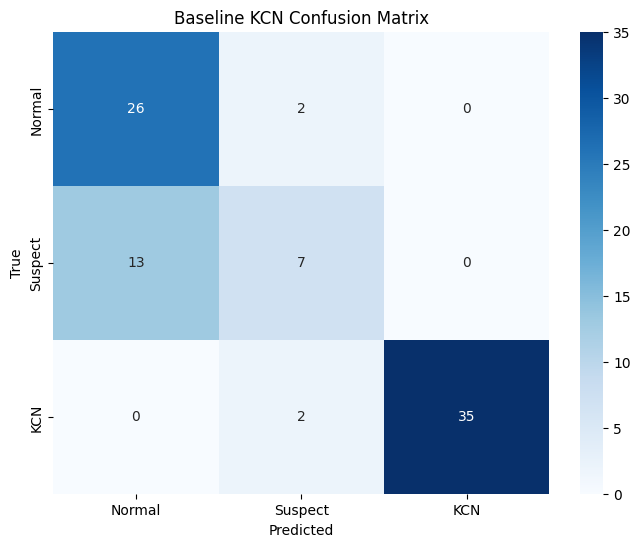

              precision    recall  f1-score   support

      Normal       0.67      0.93      0.78        28
     Suspect       0.64      0.35      0.45        20
         KCN       1.00      0.95      0.97        37

    accuracy                           0.80        85
   macro avg       0.77      0.74      0.73        85
weighted avg       0.80      0.80      0.79        85



In [19]:
# Execute the training
train_baseline(model, train_loader, val_loader)

### Model Save

In [20]:
# Define the save path in  Google Drive
save_path = '/content/drive/MyDrive/Data Science Projects/Keratoconus/simple_kcnn_modelv2.pth'

# define model saving function
def save_model(model, path):
    """Saves the current state of the model regardless of training progress."""
    try:
        # Ensure the directory exists
        os.makedirs(os.path.dirname(path), exist_ok=True)

        # Save only the state dictionary (recommended for deployment)
        torch.save(model.state_dict(), path)
        print(f"✅ Model successfully saved to: {path}")
    except Exception as e:
        print(f"❌ Error saving model: {e}")

# Execute the save
save_model(model, save_path)

✅ Model successfully saved to: /content/drive/MyDrive/Data Science Projects/Keratoconus/simple_kcnn_modelv2.pth


## Advanced CNN Model

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Increase the 'Suspect' weight significantly to force the model to prioritize it
weights = torch.tensor([1.2, 3.5, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [23]:
class KeratoconusEfficientNet(nn.Module):
    def __init__(self, num_classes=3):
        super(KeratoconusEfficientNet, self).__init__()
        # Load pre-trained weights to leverage 'fine-feature' detection
        self.base_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

        # Access the feature count before the final layer (1280 for B0)
        num_ftrs = self.base_model.classifier[1].in_features

        # Replace the final head to match your 3-class system
        self.base_model.classifier[1] = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased dropout to prevent overfitting on small data
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, 7, 3, 224, 224]
        batch_size, num_maps, c, h, w = x.size()

        # Flatten batch and maps to process all 7 images through the backbone
        x = x.view(-1, c, h, w) # New shape: [batch*7, 3, 224, 224]

        features = self.base_model(x) # Shape: [batch*7, 3]

        # Reshape back and average the predictions of the 7 maps (Mean Fusion)
        # This mimics the research's 'expert' approach for each map
        features = features.view(batch_size, num_maps, -1)
        return torch.mean(features, dim=1)

model_adv = KeratoconusEfficientNet(num_classes=3).to(device)

### Train Advanced Model

Epoch 1/30 - Loss: 1.0821
Epoch 2/30 - Loss: 1.0751
Epoch 3/30 - Loss: 1.0783
Epoch 4/30 - Loss: 1.0799
Epoch 5/30 - Loss: 1.0734
Epoch 6/30 - Loss: 1.0756
Epoch 7/30 - Loss: 1.0790
Epoch 8/30 - Loss: 1.0767
Epoch 9/30 - Loss: 1.0746
Epoch 10/30 - Loss: 1.0762
Epoch 11/30 - Loss: 1.0757
Epoch 12/30 - Loss: 1.0814
Epoch 13/30 - Loss: 1.0811
Epoch 14/30 - Loss: 1.0807
Epoch 15/30 - Loss: 1.0769
Epoch 16/30 - Loss: 1.0736
Epoch 17/30 - Loss: 1.0742
Epoch 18/30 - Loss: 1.0776
Epoch 19/30 - Loss: 1.0737
Epoch 20/30 - Loss: 1.0795
Epoch 21/30 - Loss: 1.0752
Epoch 22/30 - Loss: 1.0746
Epoch 23/30 - Loss: 1.0785
Epoch 24/30 - Loss: 1.0787
Epoch 25/30 - Loss: 1.0757
Epoch 26/30 - Loss: 1.0781
Epoch 27/30 - Loss: 1.0757
Epoch 28/30 - Loss: 1.0753
Epoch 29/30 - Loss: 1.0785
Epoch 30/30 - Loss: 1.0779


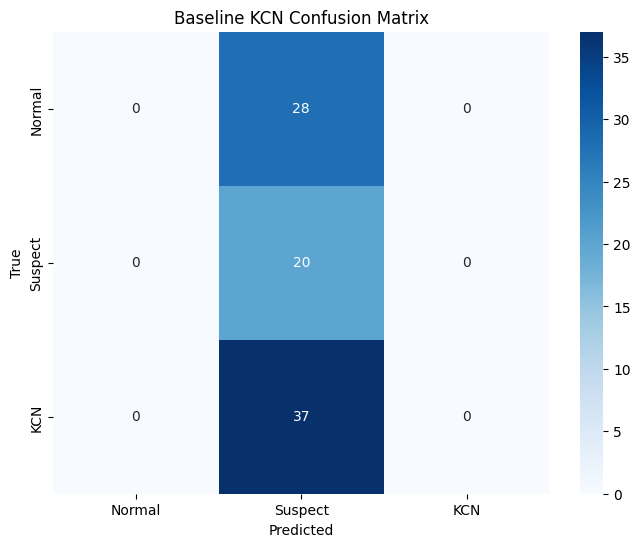

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        28
     Suspect       0.24      1.00      0.38        20
         KCN       0.00      0.00      0.00        37

    accuracy                           0.24        85
   macro avg       0.08      0.33      0.13        85
weighted avg       0.06      0.24      0.09        85



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
train_baseline(model_adv, train_loader, val_loader)